[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HannahPinson/tue-deeplearning-2AMM10/blob/main/practicals/P3.2_hf_segmentation_answer.ipynb)

In [1]:
# If needed, uncomment the next line to install the required packages.
# !pip install -q datasets transformers accelerate matplotlib pillow segmentation-models-pytorch

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import numpy as np
from torchvision.transforms import functional as VF
from datasets import load_dataset
from transformers import (
    Trainer,
    TrainingArguments,
)
from transformers.modeling_outputs import SemanticSegmenterOutput
from PIL import Image

/Users/dave/Code/tue-deeplearning-2AMM10/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Practical 3.2: Semantic segmentation via Hugging Face

In this practical we wiil:

1. consider an applied computer vision problem, namely semantic segmentation
2. implement appropriate semantic segmentation losses/metrics from scratch,
3. fine-tune pretrained UNet for semantic segmentation
4. Get a grasp of HuggingFace `Trainer` class for efficient training/evaluation


## 0. What is semantic segmentation?

<div style="text-align:left;">
  <img src="https://miro.medium.com/1*bYMPQAXjx8RzvGO2DwobGg.jpeg" width="600"/>
</div>

Semantic segmentation is equivalent to **pixel-level classification**. Instead of assigning one label to a whole image, a semantic segmentation model assigns a class label to every pixel.

For a general multi-class segmentation problem, let

$$
\mathbf{x} \in \mathbb{R}^{C \times H \times W}
$$

be an input image, where $C$ is the number of channels, $H$ is the image height, and $W$ is the image width.

The target is a pixel-wise label map

$$
\mathbf{y} \in \{0,1,\dots,K-1\}^{H \times W},
$$

where $K$ is the number of classes.

The model predicts class logits for every pixel:

$$
f_\theta(\mathbf{x}) \in \mathbb{R}^{K \times H_{\text{out}} \times W_{\text{out}}}.
$$

where typically $H_{\text{out}} \leq H$, $W_{\text{out}} \leq W$


## 1. Semantic Segmentation Loss Functions


### Cross-entropy loss

Since the task boils down to a pixel-level classification, a natural loss function is cross-entropy loss. 
For each pixel, the model outputs logits $\hat{\mathbf{z}}_{h,w} \in \mathbb{R}^{K}$. After applying softmax, we get class probabilities $\hat{\mathbf{p}}_{h,w} = \mathrm{softmax}(\hat{\mathbf{z}}_{h,w})$.

Cross-entropy compares the one-hot target vector with the predicted probability vector at each pixel:

$$
\mathcal{L}_{CE} = -\frac{1}{HW}\sum_{h=1}^{H}\sum_{w=1}^{W}\sum_{k=1}^{K} y_{h,w,k}\log \hat{p}_{h,w,k}
$$

Cross-entropy is computed **per pixel** and then averaged.

This is useful, but it can be problematic when one class dominates the image. For example, if most pixels are background (i.e sky class), the model can obtain a low loss by predicting background well while still missing the foreground object.

### Dice coefficient
<div style="text-align:left;">
  <img src="https://raw.githubusercontent.com/HannahPinson/tue-deeplearning-2AMM10/main/img/P3.2_seg_mask.png" width="800"/>
</div>

Dice measures **overlap** between a predicted mask and a ground-truth mask.

For class $k$, the ground-truth mask is a binary matrix $M_k \in \{0,1\}^{H \times W}$:

$$
M_k(h,w) =
\begin{cases}
1 & \text{if pixel } (h,w) \text{ belongs to class } k \\
0 & \text{otherwise}
\end{cases}
$$

If $P_k$ is the predicted binary mask for class $k$, then:

$$
\mathrm{Dice}_k = \frac{2|P_k \cap M_k|}{|P_k| + |M_k|}
$$

Equivalently:

$$
\mathrm{Dice}_k = \frac{2TP_k}{2TP_k + FP_k + FN_k}
$$

Therefore dice is high when the predicted mask overlaps well with the true mask.

### Soft Dice Loss

During training, we can not use hard prediction masks for loss-computation (why?). Instead, we use the model's soft probability maps.

Let $\hat{p}_{k,h,w}$ be the predicted probability that pixel $(h,w)$ belongs to class $k$. The soft Dice score for class $k$ is:

$$
\mathrm{Dice}_k = \frac{2\sum_{h,w}\hat{p}_{k,h,w}M_k(h,w) + \epsilon}{\sum_{h,w}\hat{p}_{k,h,w} + \sum_{h,w}M_k(h,w) + \epsilon}
$$

The numerator is the soft overlap between the predicted probability mask and the ground-truth mask. The denominator is the total predicted mask mass plus the total ground-truth mask mass.

For multi-class segmentation, we compute Dice for each class and average:

$$
\mathcal{L}_{Dice} = 1 - \frac{1}{K}\sum_{k=1}^{K}\mathrm{Dice}_k
$$


### Why combine cross-entropy and Dice Loss?

Dice Loss does encourage correct classification, but it does so through mask overlap rather than through an independent loss at each pixel.

Cross-entropy gives every pixel a direct classification signal. Dice Loss gives a region-level overlap signal.

In practice, they are often combined:

$$
\mathcal{L} = \mathcal{L}_{CE} + \lambda \mathcal{L}_{Dice}
$$

Cross-entropy encourages local pixel-wise classification, while Dice Loss encourages global mask-level overlap.

## Task 1: Complete `dice_loss` function following the interface described in the function's docstring

In [3]:
def dice_loss(logits, labels, num_classes, eps=1e-6):
    """
    Compute soft Dice Loss for semantic segmentation.

    Args:
        logits:
            torch.Tensor of shape (B, K, H, W).
            Raw model outputs before softmax.

        labels:
            torch.Tensor of shape (B, H, W).
            Integer class labels in {0, ..., K-1}.

        num_classes:
            int. Number of semantic classes K.

        eps:
            float. Small constant for numerical stability.

    Returns:
        loss:
            Scalar torch.Tensor.
    """

    # Convert logits to probabilities
    probs = F.softmax(logits, dim=1)

    # Convert labels to one-hot masks: (B, H, W) -> (B, H, W, K)
    labels_one_hot = F.one_hot(labels, num_classes=num_classes)

    # Rearrange to match the logits shape: (B, H, W, K) -> (B, K, H, W)
    labels_one_hot = labels_one_hot.permute(0, 3, 1, 2).float()

    # Compute Dice score for each class
    dims = (0, 2, 3)
    intersection = (probs * labels_one_hot).sum(dim=dims)
    denominator = probs.sum(dim=dims) + labels_one_hot.sum(dim=dims)

    dice_per_class = (2 * intersection + eps) / (denominator + eps)

    # Convert Dice score to Dice loss
    loss = 1 - dice_per_class.mean()

    return loss


def combined_ce_dice_loss(
    outputs, labels, num_items_in_batch=None, num_classes=2, dice_weight=1.0
):
    """
    Compute a combined Cross-Entropy + Dice loss for semantic segmentation.

    This function is designed to be passed to the Hugging Face Trainer through
    the `compute_loss_func` argument. The Trainer calls it after the model
    forward pass.

    Args:
        outputs:
            Model output object returned by the segmentation model.
            It must contain `outputs.logits` with shape (B, K, h, w),
            where B is the batch size, K is the number of classes, and
            h, w are the spatial dimensions of the logits.

        labels:
            Ground-truth segmentation masks of shape (B, H, W).
            Each pixel should contain an integer class id in
            {0, ..., K - 1}. For binary segmentation, labels should contain
            0 for background and 1 for foreground.

        num_items_in_batch:
            Optional argument passed by the Hugging Face Trainer.
            It is included to match the expected Trainer loss-function
            interface, but is not used here.

        num_classes:
            Number of segmentation classes K. For binary segmentation,
            this should be 2.

        dice_weight:
            Weight applied to the Dice loss term. The final loss is:

                cross_entropy_loss + dice_weight * dice_loss

    Returns:
        torch.Tensor:
            A scalar tensor containing the combined loss.
    """
    logits = outputs.logits

    # Some segmentation models output lower-resolution logits.
    # Resize logits so that they match the spatial size of the labels.
    if logits.shape[-2:] != labels.shape[-2:]:
        logits = F.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="nearest",
        )

    labels = labels.long()

    ce_loss = F.cross_entropy(logits, labels)

    d_loss = dice_loss(
        logits=logits,
        labels=labels,
        num_classes=num_classes,
    )

    return ce_loss + dice_weight * d_loss

## 2. Metrics for semantic segmentation

For semantic segmentation, accuracy alone is often not enough. If one class dominates the image, a model can get high accuracy by predicting that class most of the time while still performing poorly on the object of interest.

Instead, we usually evaluate segmentation using **overlap-based metrics**.

### 2.1 Intersection over Union

For class $k$, Intersection over Union measures the overlap between the predicted mask and the ground-truth mask:

$$
IoU_k = \frac{|P_k \cap M_k|}{|P_k \cup M_k|}
$$

Equivalently:

$$
IoU_k = \frac{TP_k}{TP_k + FP_k + FN_k}
$$

### 2.2 Mean IoU

In multi-class segmentation, we compute IoU separately for each class and then average:

$$
mIoU = \frac{1}{K}\sum_{k=1}^{K} IoU_k
$$

In this lab, $K=2$, so mIoU averages background IoU and foreground IoU.

### 2.3 Dataset-level IoU

In practice, IoU is usually computed over the whole validation set. We first accumulate a confusion matrix over all validation images, then derive IoU from that matrix.

This is different from computing IoU image by image and then averaging.

## Task 2. Complete the code in `compute_confusion_matrix`, `compute_accuracy_and_iou`

In [4]:
def compute_confusion_matrix(preds, labels, num_classes):
    """
    Compute the semantic segmentation confusion matrix.

    Args:
        preds:
            torch.Tensor of shape (N, H, W).
            Predicted class ids.

        labels:
            torch.Tensor of shape (N, H, W).
            Ground-truth class ids.

        num_classes:
            int. Number of semantic classes.

    Returns:
        conf_matrix:
            torch.Tensor of shape (num_classes, num_classes).

            Rows correspond to ground-truth classes.
            Columns correspond to predicted classes.
    """

    preds = preds.reshape(-1).long()
    labels = labels.reshape(-1).long()

    conf_matrix = torch.zeros(
        (num_classes, num_classes),
        dtype=torch.long,
        device=preds.device,
    )

    # Count how often each true/predicted class pair occurs.
    for true_class in range(num_classes):
        for pred_class in range(num_classes):
            conf_matrix[true_class, pred_class] = (
                (labels == true_class) & (preds == pred_class)
            ).sum()

    return conf_matrix


def compute_accuracy_and_iou(conf_matrix):
    """
    Compute pixel accuracy and mean Intersection-over-Union from a confusion matrix.

    Args:
        conf_matrix:
            torch.Tensor of shape (C, C), where C is the number of classes.

            Rows correspond to ground-truth classes.
            Columns correspond to predicted classes.

            Entry conf_matrix[i, j] contains the number of pixels whose
            true class is i and predicted class is j.

    Returns:
        metrics:
            dict containing:
            - "accuracy":
                Pixel accuracy over all classes.

            - "mean_iou":
                Mean Intersection-over-Union averaged over valid classes.
    """

    conf_matrix = conf_matrix.float()

    true_positives = torch.diag(conf_matrix)

    accuracy = true_positives.sum() / conf_matrix.sum().clamp(min=1)

    false_positives = conf_matrix.sum(dim=0) - true_positives
    false_negatives = conf_matrix.sum(dim=1) - true_positives

    iou_denominator = true_positives + false_positives + false_negatives
    per_class_iou = true_positives / iou_denominator.clamp(min=1)

    valid_classes = iou_denominator > 0
    mean_iou = per_class_iou[valid_classes].mean()

    return {
        "accuracy": accuracy,
        "mean_iou": mean_iou,
    }


def compute_metrics(eval_pred, num_classes=2):
    """
    Compute evaluation metrics for Hugging Face Trainer.

    The Trainer passes model predictions and labels to this function.
    We convert logits to predicted class ids, build a confusion matrix,
    and return pixel accuracy and mean IoU.

    Args:
        eval_pred:
            Tuple containing:
            - logits:
                Model predictions of shape (N, C, h, w), where C is the
                number of classes.

            - labels:
                Ground-truth segmentation masks of shape (N, H, W).

        num_classes:
            Number of semantic classes. For binary segmentation, this is 2.

    Returns:
        metrics:
            dict containing Python floats:
            - "accuracy"
            - "mean_iou"
    """

    logits, labels = eval_pred

    # Some models return predictions as a tuple.
    # The logits are the first element.
    if isinstance(logits, tuple):
        logits = logits[0]

    logits = torch.as_tensor(logits)
    labels = torch.as_tensor(labels).long()

    # Some segmentation models output lower-resolution logits.
    # Resize logits so that they match the spatial size of the labels.
    if logits.shape[-2:] != labels.shape[-2:]:
        logits = F.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="nearest",
        )

    preds = logits.argmax(dim=1)

    conf_matrix = compute_confusion_matrix(
        preds=preds,
        labels=labels,
        num_classes=num_classes,
    )

    metrics = compute_accuracy_and_iou(conf_matrix)

    return {
        "accuracy": metrics["accuracy"].item(),
        "mean_iou": metrics["mean_iou"].item(),
    }

## 3. Load the Fantastic Beasts segmentation dataset

We will now load a Fantastic-Beasts dataset from the Hugging Face Hub, via the `load_dataset` function

The segmentation masks contain two classes:

```text
0 = background
1 = beast
```

To keep the practical fast, we use a small training and validation subset.


In [5]:
dataset_name = "chaofanma/Fantastic-Beasts"

# This dataset only provides a test split.
# For this practical, we load that split and manually create
# a small train/validation split from it.
dataset = load_dataset(dataset_name, split="test")

# Shuffle before splitting so that train and validation examples are mixed.
dataset = dataset.shuffle(seed=42)

# Keep the practical small enough to run quickly.
num_examples = min(200, len(dataset))
num_train = int(0.8 * num_examples)

dataset = dataset.select(range(num_examples))

# Use column names that match the image processor API.
if "image" in dataset.column_names:
    dataset = dataset.rename_column("image", "images")

if "mask" in dataset.column_names:
    dataset = dataset.rename_column("mask", "segmentation_maps")

train_raw = dataset.select(range(num_train))
val_raw = dataset.select(range(num_train, num_examples))

print(train_raw)
print(val_raw)

Dataset({
    features: ['images', 'segmentation_maps', 'category', 'attributes'],
    num_rows: 160
})
Dataset({
    features: ['images', 'segmentation_maps', 'category', 'attributes'],
    num_rows: 40
})


Let's inspect an image with the corresponding label

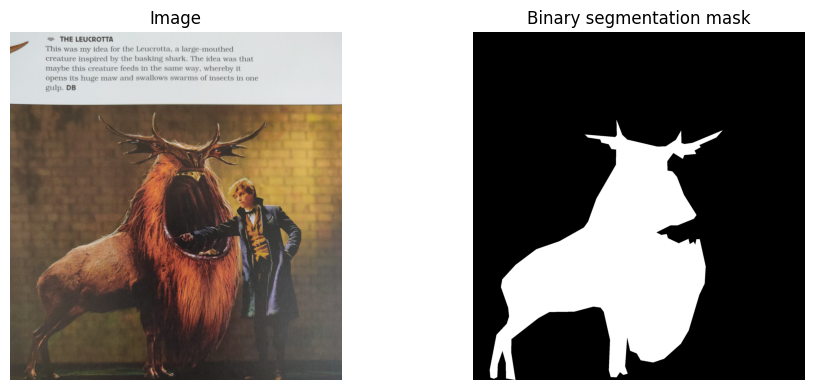

Unique mask values: [  0 255]


In [6]:
example = train_raw[0]

image = example["images"]
mask = example["segmentation_maps"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Binary segmentation mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Unique mask values:", np.unique(np.array(mask)))

## 4. Load a pretrained UNet

As shown in the tutorial, the Hugging Face `transformers` library allows us to easily load pretrained models using the `AutoModel*` classes (e.g. `AutoModelForImageClassification`, `AutoModelForSemanticSegmentation`).
Similarly, we can load the corresponding image processors with `AutoImageProcessor`.

However, **not all models available on the Hugging Face Hub follow the `Auto*` interface** (this is mostly true for newer transformer-based architectures).

To work around this, we provide a custom wrapper: `UNetForSemanticSegmentation`, together with a matching `UNetImageProcessor`.

At a high level, given the arguments `encoder_name`, `encoder_weights`, and `num_classes`, these classes define a UNet architecture:

- `encoder_name` selects the backbone (e.g. `"resnet18"`),
- `encoder_weights` specifies how the encoder is initialized (e.g. `"imagenet"` for pretrained weights),
- `num_classes` determines the number of output segmentation channels.

These classes act as a lightweight replacement for the `Auto*` abstraction.

Importantly, their inputs and outputs are designed to match the interface expected by the Hugging Face `Trainer`:
- the processor returns `pixel_values` and `labels`,
- the model returns an object containing `outputs.logits`.

This allows us to use the `Trainer` exactly as before, even though the underlying model is not part of the standard Hugging Face model zoo.

In [7]:
class UNetForSemanticSegmentation(nn.Module):
    """
    UNet wrapper compatible with the Hugging Face Trainer.

    This class uses segmentation_models_pytorch to create a UNet model,
    but exposes a Hugging Face-style forward method and output object.

    Args:
        encoder_name:
            Name of the encoder/backbone used by the UNet.
            Examples: "resnet18", "resnet34", "mobilenet_v2".

        num_classes:
            Number of semantic segmentation classes.
            For binary segmentation with background/foreground labels,
            this should be 2.

        encoder_weights:
            Pretrained weights for the encoder.
            Use "imagenet" for ImageNet-pretrained encoders, or None
            for random initialization.
    """

    def __init__(
        self,
        encoder_name="resnet18",
        num_classes=2,
        encoder_weights="imagenet",
    ):
        super().__init__()

        self.num_classes = num_classes

        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=num_classes,
            activation=None,
        )

    def forward(self, pixel_values, labels=None):
        """
        Run a forward pass.

        Args:
            pixel_values:
                Input images as a torch.Tensor of shape (B, 3, H, W).

            labels:
                Optional segmentation masks of shape (B, H, W).
                This argument is included for Trainer compatibility.
                The custom loss function computes the loss, so labels
                are not used inside this forward method.

        Returns:
            SemanticSegmenterOutput containing:
            - logits: torch.Tensor of shape (B, num_classes, H, W)
        """

        logits = self.unet(pixel_values)

        return SemanticSegmenterOutput(
            logits=logits,
        )


class UNetImageProcessor:
    """
    Lightweight image processor for UNet semantic segmentation.

    This class is designed to be used with Hugging Face Dataset.with_transform.
    It converts PIL images and segmentation masks into tensors suitable for
    the Hugging Face Trainer.

    Args:
        encoder_name:
            Name of the UNet encoder/backbone.
            This should match the encoder_name used in UNetForSemanticSegmentation.

        encoder_weights:
            Pretrained encoder weights.
            Use "imagenet" when using an ImageNet-pretrained encoder.

        size:
            Output spatial size as (height, width).

    Returns:
        A transformed batch containing:
        - "pixel_values": torch.Tensor of shape (B, 3, H, W)
        - "labels": torch.Tensor of shape (B, H, W)
    """

    def __init__(
        self,
        encoder_name="resnet18",
        encoder_weights="imagenet",
        size=(256, 256),
    ):
        self.encoder_name = encoder_name
        self.encoder_weights = encoder_weights
        self.size = size

        preprocessing_params = smp.encoders.get_preprocessing_params(
            encoder_name,
            pretrained=encoder_weights,
        )

        self.mean = preprocessing_params["mean"]
        self.std = preprocessing_params["std"]

    def __call__(self, examples):
        images = examples["images"]
        masks = examples["segmentation_maps"]

        pixel_values = []
        labels = []

        for image, mask in zip(images, masks):
            # Ensure image is RGB.
            image = image.convert("RGB")

            # Resize image and mask.
            image = image.resize(
                self.size[::-1],
                resample=Image.BILINEAR,
            )

            mask = mask.resize(
                self.size[::-1],
                resample=Image.NEAREST,
            )

            # Convert image to tensor in [0, 1].
            image_tensor = VF.to_tensor(image)

            # Normalize using the preprocessing statistics expected
            # by the pretrained encoder.
            image_tensor = VF.normalize(
                image_tensor,
                mean=self.mean,
                std=self.std,
            )

            mask_array = np.array(mask)

            # Convert {0, 255} -> {0, 1}
            mask_array = (mask_array > 0).astype(np.int64)

            mask_tensor = torch.as_tensor(mask_array, dtype=torch.long)

            pixel_values.append(image_tensor)
            labels.append(mask_tensor)

        return {
            "pixel_values": torch.stack(pixel_values),
            "labels": torch.stack(labels),
        }


# Feel free to read the UNetForSemanticSegmentation and UNetImageProcessor code above to understand how they work.
# However they are not prerequisite for the rest of the practical, so you can skip reading them for now.
# As a mental abstraction, these classes implement the same interface (input/output format) as AutoModel, AuttoImageProcessor.

encoder_name = "resnet18"
encoder_weights = "imagenet"

image_processor = UNetImageProcessor(
    encoder_name=encoder_name,
    encoder_weights=encoder_weights,
    size=(256, 256),
)
model = UNetForSemanticSegmentation(
    encoder_name=encoder_name,
    num_classes=2,
    encoder_weights=encoder_weights,
)

## 5. Dataset transforms

The raw dataset contains:

- **images**: `PIL.Image` (RGB), shape `(H, W, 3)`
- **segmentation_maps**: `PIL.Image` (mask), shape `(H, W)` with values `{0, 255}`

The model does not use PIL images directly. It expects:

- **pixel_values**: image tensor  
- **labels**: segmentation mask tensor

We apply preprocessing lazily using:

```python
dataset.with_transform(image_processor)
```

The `UNetImageProcessor` converts:

- `images            → pixel_values` (`torch.FloatTensor`, `(3, H, W)`)
- `segmentation_maps → labels`       (`torch.LongTensor`,  `(H, W)`)


In [8]:
train_dataset = train_raw.with_transform(image_processor)
val_dataset = val_raw.with_transform(image_processor)

sample = train_dataset[0]

print(sample.keys())
print("pixel_values shape:", sample["pixel_values"].shape)
print("labels shape:", sample["labels"].shape)
print("Unique processed labels:", torch.unique(sample["labels"]))

dict_keys(['pixel_values', 'labels'])
pixel_values shape: torch.Size([3, 256, 256])
labels shape: torch.Size([256, 256])
Unique processed labels: tensor([0, 1])


## 8. Configure the Hugging Face Trainer

The Hugging Face `Trainer` automates the training and evaluation loop.

Instead of writing a manual loop, we define a `Trainer` and let it handle:

- forward pass
- loss computation
- backpropagation
- evaluation and logging

---

### What does the Trainer need?

```text
model
training arguments
training dataset
validation dataset
loss function
metrics function
```

In this practical:

- **Loss**: cross-entropy + Dice loss  
- **Metrics**: accuracy and mean IoU  

Since our model does not compute the loss internally, we pass:

```python
compute_loss_func=combined_ce_dice_loss
```

---

### Training configuration

`TrainingArguments` defines how training runs:

```text
epochs, batch size, learning rate, evaluation, logging
```

It also handles:

```text
device selection (CPU / GPU), mixed precision, distributed training
```

---

### Data flow

```text
batch (pixel_values, labels)
        ↓
model → logits
        ↓
loss function
        ↓
update
```

In [9]:
training_args = TrainingArguments(
    learning_rate=5e-4,
    num_train_epochs=10,
    per_device_train_batch_size=16,  # The train batch size per device. The global batch size is computed as: per_device_train_batch_size * number_of_devices in multi-GPU or distributed setups.
    per_device_eval_batch_size=16,  # Same as above, but for evaluation.
    eval_strategy="epoch",  # When to run evaluation during training. "epoch" means after each epoch. "no" means never evaluate during training. "steps" means evaluate every X steps, where X is specified by the logging_steps argument.
    use_cpu=False,  #  Whether or not to use cpu. If set to False, we will use the available torch device/backend. By default, the Trainer will use a GPU if available, and fall back to CPU otherwise.
    remove_unused_columns=False,  # Don't remove columns from the dataset, since our model expects "pixel_values" and "labels".
    logging_strategy="epoch",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_loss_func=combined_ce_dice_loss,
    compute_metrics=compute_metrics,
)

## 9. Evaluate before fine-tuning

Before training, we evaluate the model once.

This gives us a baseline. The segmentation head is newly initialized, so the model should not perform well yet.


In [10]:
baseline_metrics = trainer.evaluate()
baseline_metrics

/Users/dave/Code/tue-deeplearning-2AMM10/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/dave/Code/tue-deeplearning-2AMM10/.venv/lib/python3.14/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Training Loss,Validation Loss,Epoch,Accuracy,Mean Iou
No log,1.322998,0,0.336095,0.181017


{'eval_loss': 1.3229984045028687,
 'eval_accuracy': 0.3360946774482727,
 'eval_mean_iou': 0.18101650476455688}

## 10. Fine-tune the model

Now we fine-tune the model on the Fantastic Beasts training subset.

This practical uses only a few epochs so that it runs quickly. With more time, you could train for more epochs and use a larger validation set.


In [11]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Mean Iou
1,0.819653,5.506220,0.466771,0.297137
2,0.521572,1.113899,0.806873,0.665298
3,0.379135,0.447273,0.901395,0.803248
4,0.292682,0.341536,0.923652,0.834082
5,0.237386,0.345704,0.922378,0.831970
6,0.201961,0.301956,0.932590,0.853209
7,0.186246,0.281555,0.937372,0.863336
8,0.162249,0.279489,0.938438,0.867031
9,0.162449,0.271176,0.939923,0.869744
10,0.151265,0.268905,0.940184,0.871326


/Users/dave/Code/tue-deeplearning-2AMM10/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/dave/Code/tue-deeplearning-2AMM10/.venv/lib/python3.14/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


TrainOutput(global_step=100, training_loss=0.3114597678184509, metrics={'train_runtime': 57.9494, 'train_samples_per_second': 27.61, 'train_steps_per_second': 1.726, 'total_flos': 0.0, 'train_loss': 0.3114597678184509, 'epoch': 10.0})

## 13. Visualize segmentation predictions

Metrics are useful, but segmentation should also be inspected visually!

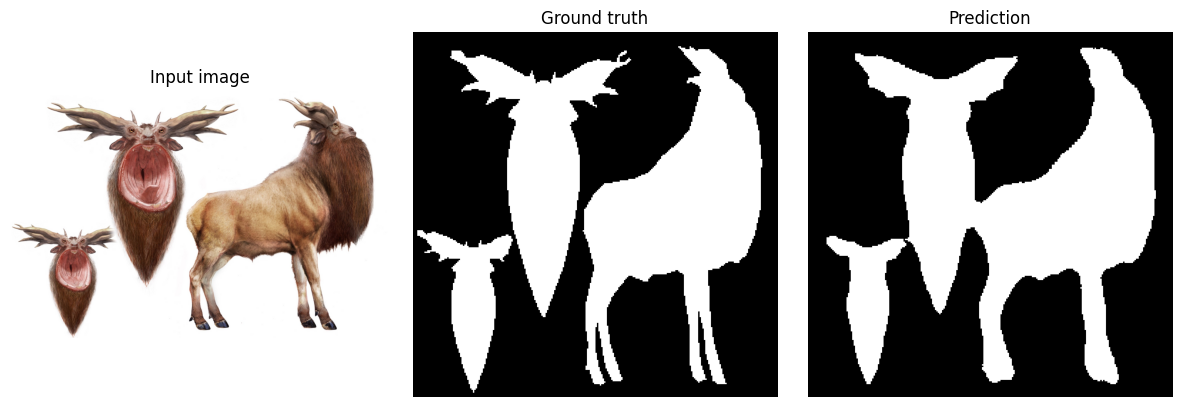

In [16]:
def visualize_prediction(model, raw_dataset, processed_dataset, index=0):
    """
    Visualize one image, its ground-truth mask, and the model prediction.
    """

    model.eval()

    raw_example = raw_dataset[index]
    processed_example = processed_dataset[index]

    image = raw_example["images"]
    label = processed_example["labels"]

    # Get the device where the model lives after Trainer training.
    device = next(model.parameters()).device

    # Move input to the same device as the model.
    pixel_values = processed_example["pixel_values"].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    logits = outputs.logits

    if logits.shape[-2:] != label.shape[-2:]:
        logits = F.interpolate(
            logits,
            size=label.shape[-2:],
            mode="nearest",
        )

    pred = logits.argmax(dim=1).squeeze(0).cpu()
    label = label.cpu()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(label, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    axes[2].imshow(pred, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


### Play around with the index (dataset sample index) to see how different predictions look like.
visualize_prediction(
    model=model,
    raw_dataset=val_raw,
    processed_dataset=val_dataset,  # Notice that we use the validation dataset here, since the training dataset samples are seen during training and the predictions will look better.
    index=10,
)